<a href="https://colab.research.google.com/github/ucaokylong/Some_small_projects/blob/main/Knowledge_distillation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Tải xuống dataset Weather từ Google Drive
!gdown 1fnJMMw0LvDgl-GS4FTou5qAgLxOE2KQ0
!unzip img_cls_weather_dataset.zip  # Giải nén


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: weather-dataset/dataset/frost/3922.jpg  
  inflating: weather-dataset/dataset/frost/3923.jpg  
  inflating: weather-dataset/dataset/frost/3924.jpg  
  inflating: weather-dataset/dataset/frost/3925.jpg  
  inflating: weather-dataset/dataset/frost/3926.jpg  
  inflating: weather-dataset/dataset/frost/3927.jpg  
  inflating: weather-dataset/dataset/frost/3928.jpg  
  inflating: weather-dataset/dataset/frost/3929.jpg  
  inflating: weather-dataset/dataset/frost/3930.jpg  
  inflating: weather-dataset/dataset/frost/3931.jpg  
  inflating: weather-dataset/dataset/frost/3932.jpg  
  inflating: weather-dataset/dataset/frost/3933.jpg  
  inflating: weather-dataset/dataset/frost/3934.jpg  
  inflating: weather-dataset/dataset/frost/3935.jpg  
  inflating: weather-dataset/dataset/frost/3936.jpg  
  inflating: weather-dataset/dataset/frost/3937.jpg  
  inflating: weather-dataset/dataset/frost/3938.jpg  
  inflating: weather-data

In [2]:
import os
import timm
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Thiết lập seed
seed = 59
set_seed(seed)


In [4]:
# Đường dẫn đến thư mục dataset
root_dir = 'weather-dataset/dataset'

# Tạo dictionary để lưu thông tin các lớp
classes = {
    label_idx: class_name \
    for label_idx, class_name in enumerate(
        sorted(os.listdir(root_dir))
    )
}

# Tạo danh sách đường dẫn ảnh và nhãn
img_paths = []
labels = []

for label_idx, class_name in classes.items():
    class_dir = os.path.join(root_dir, class_name)
    for img_filename in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_filename)
        img_paths.append(img_path)
        labels.append(label_idx)


In [5]:
# Thiết lập tỷ lệ chia
val_size = 0.2
test_size = 0.125
is_shuffle = True

# Chia train và validation
X_train, X_val, y_train, y_val = train_test_split(img_paths, labels,
                                                  test_size=val_size,
                                                  random_state=seed,shuffle=is_shuffle)

# Chia train và test
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle
)


In [6]:
class WeatherDataset(Dataset):
    def __init__(self,
                 X, y,
                 transform=None
                ):
        self.transform = transform
        self.img_paths = X
        self.labels = y

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

def transform(img, img_size=(224, 224)):
    img = img.resize(img_size)
    img = np.array(img)[..., :3]
    img = torch.tensor(img).permute(2, 0, 1).float()
    normalized_img = img / 255.0

    return normalized_img

# Tạo các dataset
train_dataset = WeatherDataset(
    X_train, y_train,
    transform=transform
)

val_dataset = WeatherDataset(
    X_val, y_val,
    transform=transform
)

test_dataset = WeatherDataset(
    X_test, y_test,
    transform=transform
)


In [13]:
# Student
train_batch_size = 256
# Teacher
train_batch_size = 64

test_batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False
)


In [16]:
n_classes = len(list(classes.keys()))
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Student
model_student = timm.create_model(
    'resnet18',
    pretrained=True,
    num_classes=n_classes
).to(device)




In [17]:
# Teacher
model_teacher = timm.create_model(
    'densenet169',
    pretrained=True,
    num_classes=n_classes
).to(device)

In [24]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    losses = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = sum(losses) / len(losses)
    acc = correct / total

    return loss, acc

def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience
):
    train_losses = []
    val_losses = []
    val_accs = []

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        batch_train_losses = []

        model.train()
        for idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss, val_acc = evaluate(
            model, val_loader,
            criterion, device
        )
        val_accs.append(val_acc)
        val_losses.append(val_loss)

        print(f'EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\tVal acc: {val_acc:.4f}')

        # Check early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

    return train_losses, val_losses, val_accs

# Thiết lập hyperparameters
lr = 1e-4
epochs = 40
patience = 8

criterion = nn.CrossEntropyLoss()
optimizer_student = torch.optim.SGD(
    model_student.parameters(),
    lr=lr
)

optimizer_teacher = torch.optim.SGD(
    model_teacher.parameters(),
    lr=lr
)

EPOCH 1:	Train loss: 0.6007	Val loss: 0.6313	Val acc: 0.8172
EPOCH 2:	Train loss: 0.6042	Val loss: 0.6362	Val acc: 0.8165
EPOCH 3:	Train loss: 0.6018	Val loss: 0.6317	Val acc: 0.8179
EPOCH 4:	Train loss: 0.5905	Val loss: 0.6289	Val acc: 0.8179
EPOCH 5:	Train loss: 0.6112	Val loss: 0.6285	Val acc: 0.8165
EPOCH 6:	Train loss: 0.6022	Val loss: 0.6322	Val acc: 0.8150
EPOCH 7:	Train loss: 0.5968	Val loss: 0.6351	Val acc: 0.8114
EPOCH 8:	Train loss: 0.5834	Val loss: 0.6403	Val acc: 0.8172
EPOCH 9:	Train loss: 0.6019	Val loss: 0.6447	Val acc: 0.8172
EPOCH 10:	Train loss: 0.5817	Val loss: 0.6347	Val acc: 0.8201
EPOCH 11:	Train loss: 0.5969	Val loss: 0.6515	Val acc: 0.8157
EPOCH 12:	Train loss: 0.5959	Val loss: 0.6252	Val acc: 0.8172
EPOCH 13:	Train loss: 0.5907	Val loss: 0.6191	Val acc: 0.8172
EPOCH 14:	Train loss: 0.5854	Val loss: 0.6293	Val acc: 0.8172
EPOCH 15:	Train loss: 0.5927	Val loss: 0.6227	Val acc: 0.8194
EPOCH 16:	Train loss: 0.5741	Val loss: 0.6341	Val acc: 0.8157
EPOCH 17:	Train l

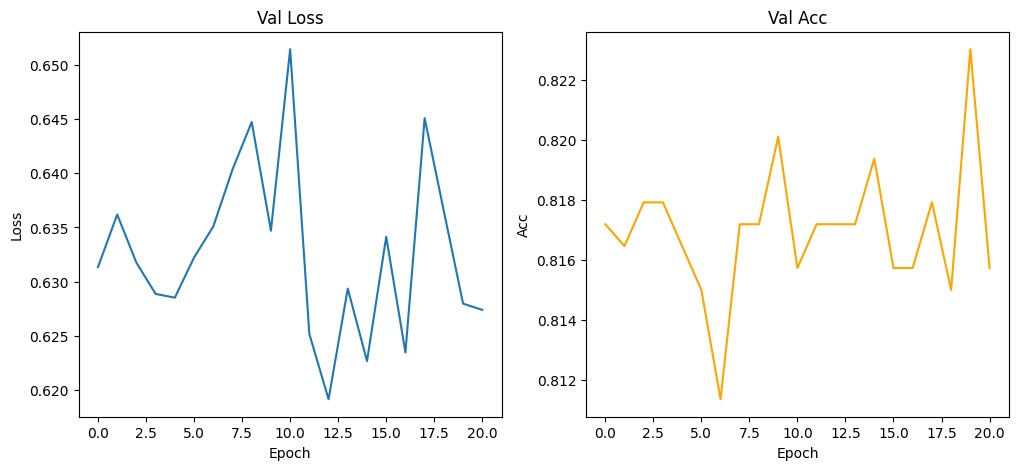

In [25]:
# Huấn luyện mô hình
train_losses_student, val_losses_student, val_accs_student = fit(
    model_student,
    train_loader,
    val_loader,
    criterion,
    optimizer_student,
    device,
    epochs,
    patience
)

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(val_losses_student)
ax[0].set_title('Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_accs_student, color = 'orange')
ax[1].set_title('Val Acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Acc')
plt.show()


EPOCH 1:	Train loss: 0.9334	Val loss: 0.9314	Val acc: 0.8077
EPOCH 2:	Train loss: 0.9289	Val loss: 0.9283	Val acc: 0.8048
EPOCH 3:	Train loss: 0.9017	Val loss: 0.9102	Val acc: 0.8128
EPOCH 4:	Train loss: 0.8978	Val loss: 0.8838	Val acc: 0.8128
EPOCH 5:	Train loss: 0.8658	Val loss: 0.8651	Val acc: 0.8157
EPOCH 6:	Train loss: 0.8462	Val loss: 0.8501	Val acc: 0.8237
EPOCH 7:	Train loss: 0.8412	Val loss: 0.8372	Val acc: 0.8165
EPOCH 8:	Train loss: 0.8317	Val loss: 0.8253	Val acc: 0.8172
EPOCH 9:	Train loss: 0.8143	Val loss: 0.8119	Val acc: 0.8252
EPOCH 10:	Train loss: 0.7988	Val loss: 0.8086	Val acc: 0.8288
EPOCH 11:	Train loss: 0.7854	Val loss: 0.7814	Val acc: 0.8267
EPOCH 12:	Train loss: 0.7643	Val loss: 0.7705	Val acc: 0.8361
EPOCH 13:	Train loss: 0.7597	Val loss: 0.7612	Val acc: 0.8390
EPOCH 14:	Train loss: 0.7439	Val loss: 0.7562	Val acc: 0.8376
EPOCH 15:	Train loss: 0.7376	Val loss: 0.7407	Val acc: 0.8369
EPOCH 16:	Train loss: 0.7201	Val loss: 0.7275	Val acc: 0.8449
EPOCH 17:	Train l

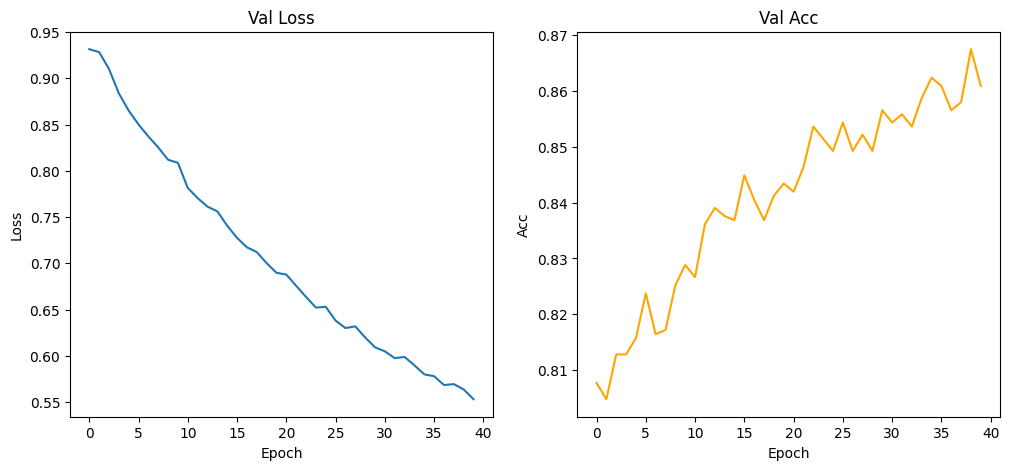

In [27]:
# Huấn luyện mô hình
train_losses_teacher, val_losses_teacher, val_accs_teacher = fit(
    model_teacher,
    train_loader,
    val_loader,
    criterion,
    optimizer_teacher,
    device,
    epochs,
    patience
)

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(val_losses_teacher)
ax[0].set_title('Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_accs_teacher, color = 'orange')
ax[1].set_title('Val Acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Acc')
plt.show()


In [28]:
# Đánh giá mô hình trên validation và test set
val_loss_student, val_acc_student = evaluate(
    model_student,
    val_loader,
    criterion,
    device
)

test_loss_student, test_acc_student = evaluate(
    model_student,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset with student model')
print('Val accuracy: ', val_acc_student)
print('Test accuracy: ', test_acc_student)


# Student:
# Val accuracy: 0.6598689002184996
# Test accuracy: 0.6462882096069869

# Teacher:
# Val accuracy: 0.8659868900218499
# Test accuracy: 0.8879184861717613


Evaluation on val/test dataset with student model
Val accuracy:  0.8157319737800437
Test accuracy:  0.8020378457059679


In [29]:
# Đánh giá mô hình trên validation và test set
val_loss_teacher, val_acc_teacher = evaluate(
    model_teacher,
    val_loader,
    criterion,
    device
)

test_loss_teacher, test_acc_teacher = evaluate(
    model_teacher,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset with teacher model')
print('Val accuracy: ', val_acc_teacher)
print('Test accuracy: ', test_acc_teacher)

# Student:
# Val accuracy: 0.6598689002184996
# Test accuracy: 0.6462882096069869

# Teacher:
# Val accuracy: 0.8659868900218499
# Test accuracy: 0.8879184861717613


Evaluation on val/test dataset with teacher model
Val accuracy:  0.8608885651857247
Test accuracy:  0.8558951965065502


In [30]:
# Lưu mô hình Teacher để chuẩn bị cho Knowledge Distillation
save_path = '/content/teacher_wt.pt'
torch.save(model_teacher.state_dict(), save_path)


## Thiết lập huấn luyện mô hình Student với Knowledge Distillation

In [32]:
# Thiết lập số classes và device
n_classes = len(list(classes.keys()))
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Tạo mô hình Teacher (DenseNet169)
teacher_model_kd = timm.create_model(
    'densenet169',
    pretrained=True,
    num_classes=n_classes).to(device)

# Load trọng số đã huấn luyện cho Teacher
teacher_model_kd.load_state_dict(
    torch.load(
        '/content/teacher_wt.pt',
        map_location=device
    )
)

# Tạo mô hình Student (ResNet18)
student_model_kd = timm.create_model(
    'resnet18',
    pretrained=True,
    num_classes=n_classes).to(device)


In [36]:
def fit(
    teacher,
    student,
    T,
    soft_target_loss_weight,
    ce_loss_weight,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience
):
    train_losses = []
    val_losses = []
    val_accs = []
    teacher.eval()

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        batch_train_losses = []

        student.train()
        for idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher(inputs)
            student_logits = student(inputs)

            # Soft targets từ teacher
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)

            # Soft target loss
            soft_targets_loss = torch.sum(soft_targets * (soft_targets.log() - soft_prob)) / soft_prob.size()[0] * (T**2)

            # Label loss (Cross Entropy)
            label_loss = criterion(student_logits, labels)

            # Tổng loss
            loss = soft_target_loss_weight * soft_targets_loss + ce_loss_weight * label_loss

            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        # Đánh giá trên validation set
        val_loss, val_acc = evaluate(
            student, val_loader,
            criterion, device
        )
        val_accs.append(val_acc)
        val_losses.append(val_loss)

        print(f'EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\tVal acc: {val_acc:.4f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

    return train_losses, val_losses, val_accs




In [37]:
optimizer_student_kd = torch.optim.SGD(
    student_model_kd.parameters(),
    lr=lr
)

In [ ]:
# Thiết lập hyperparameters cho Knowledge Distillation
train_losses_kd, val_losses_kd, val_accs_kd = fit(
    teacher_model_kd,
    student_model_kd,
    2,          # Temperature T
    0.25,       # soft_target_loss_weight
    0.75,       # ce_loss_weight
    train_loader,
    val_loader,
    criterion,
    optimizer_student_kd,
    device,
    epochs,
    patience
)


# Tương tự như Student (không KD)
# ...


EPOCH 1:	Train loss: 2.3564	Val loss: 2.4425	Val acc: 0.0823
EPOCH 2:	Train loss: 2.3432	Val loss: 2.4347	Val acc: 0.0889
EPOCH 3:	Train loss: 2.3445	Val loss: 2.4290	Val acc: 0.0983
EPOCH 4:	Train loss: 2.3367	Val loss: 2.4243	Val acc: 0.0910
EPOCH 5:	Train loss: 2.3271	Val loss: 2.4138	Val acc: 0.0889
EPOCH 6:	Train loss: 2.3224	Val loss: 2.4080	Val acc: 0.1027


In [ ]:
# Đánh giá mô hình trên validation và test set
val_loss_kd, val_acc_kd = evaluate(
    student_model_kd,
    val_loader,
    criterion,
    device
)

test_loss_kd, test_acc_kd = evaluate(
    student_model_kd,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset with student model')
print('Val accuracy: ', val_acc_student)
print('Test accuracy: ', test_acc_student)
